#Step 1)
In Python, we first import toolkits that other programmers have already built for us. We will also connect to Google Drive so the code can access our image files.

In [1]:
# 1. Connect to our Google Drive where the images are stored
# from google.colab import drive
# drive.mount('/content/drive')

# 2. Download special toolkits for tracking cells and opening image files
!pip install trackpy tifffile

# 3. Open our toolboxes so we can use the tools inside them
import numpy as np           # A toolkit for doing math with numbers
import tifffile as tiff      # A toolkit for opening scientific image files
import pandas as pd          # A toolkit for creating Excel-like data tables
import trackpy as tp         # A toolkit specifically designed to track moving dots
from skimage import filters  # A toolkit for applying filters (like blurring) to images
import matplotlib.pyplot as plt # A toolkit for making graphs and figures

#Step 2) Opening the Images
Our images are saved as .tif files. We have two separate "channels": one channel shows the Histone-RFP and one shows Knirps-Llamatag-GFP

In [2]:
# # 1. Tell the computer exactly where the files are saved on the hard drive
# !pwd
path_his = '/Users/hugo/Desktop/fall_2026_temperature_analysis/2026_04_04_Kni_His_A20_P26_histone_channel.tif'
path_kni = '/Users/hugo/Desktop/fall_2026_temperature_analysis/2026_04_04_Kni_His_A20_P26_knirps_channel.tif'

# 2. Ask the 'tiff' tool to open the images and save them into the computer's memory
img_his = tiff.imread(path_his)
img_kni = tiff.imread(path_kni)


t_start=0

img_his=img_his[t_start:]
img_kni=img_kni[t_start:]


# 3. Figure out how many frames (pictures) are in our time-lapse video
num_frames = img_his.shape[0]

In [3]:
np.shape(img_his)

(111, 324, 908)

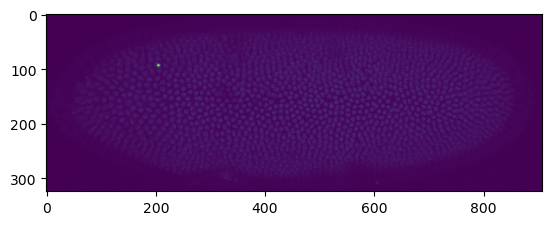

In [4]:
# 4. Plot the Histone image to see if it was loaded successfully

time_point=40
plt.imshow(img_his[time_point])


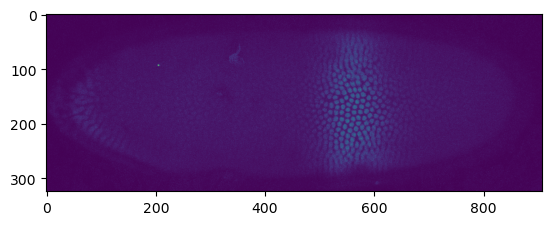

In [5]:
#5. Plot the Knirps image to see if it was loaded successfully
plt.imshow(img_kni[40])

# Step 3) Segmenting the nuclei
The computer doesn't know what a "cell" is; it just sees a grid of numbers representing dark and bright pixels. We need to create a black-and-white mask where cells are white (1) and the background is black (0). We do this by setting a "threshold"—anything brighter than a certain number becomes a cell. We also filter out tiny specks of dust (anything smaller than 15 pixels).

In [6]:
import numpy as np
from skimage import exposure, filters, morphology

# Grab the very first picture (frame)
current_frame = img_his[0]

# --- 1. Normalize the Contrast ---
# Find the darkest 1% and brightest 99.5% of the image
p1, p99 = np.percentile(current_frame, (1, 99.5))

# Stretch the contrast so the image math is scaled perfectly between 0.0 and 1.0
norm_his = exposure.rescale_intensity(current_frame, in_range=(p1, p99), out_range=(0, 1))

# --- 2. Blur the Image ---
# Smooth out grainy static so we don't accidentally threshold noise
blurred_image = filters.gaussian(norm_his, sigma=1)

# --- 3. Adaptive Thresholding ---
# Look at 35x35 pixel blocks. The offset of 0.02 helps penalize the background.
local_thresh = filters.threshold_local(blurred_image, block_size=35, offset=0.02)

# Create the Black & White mask!
bw_adaptive = blurred_image > local_thresh

# --- 4. Clean Up the Mask ---
# Remove stray "dust" smaller than 15 pixels, and fill in hollow holes inside cells
bw_clean = morphology.remove_small_objects(bw_adaptive, min_size=15)
bw_clean = morphology.remove_small_holes(bw_clean, area_threshold=15)

print("Segmentation complete! The image is now a clean black-and-white mask.")

Segmentation complete! The image is now a clean black-and-white mask.


/var/folders/vb/c6js107j1y7_pw6gnwh1yxg40000gp/T/ipykernel_36562/2755703726.py:27: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bw_clean = morphology.remove_small_objects(bw_adaptive, min_size=15)
/var/folders/vb/c6js107j1y7_pw6gnwh1yxg40000gp/T/ipykernel_36562/2755703726.py:28: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed

Let's demonstrate what thresholding really does

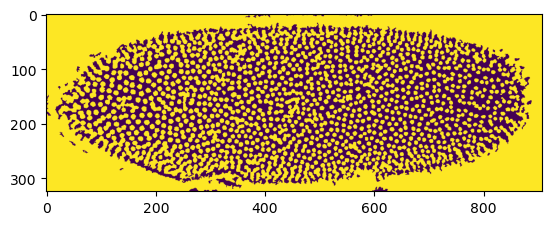

In [7]:
plt.imshow(bw_clean)

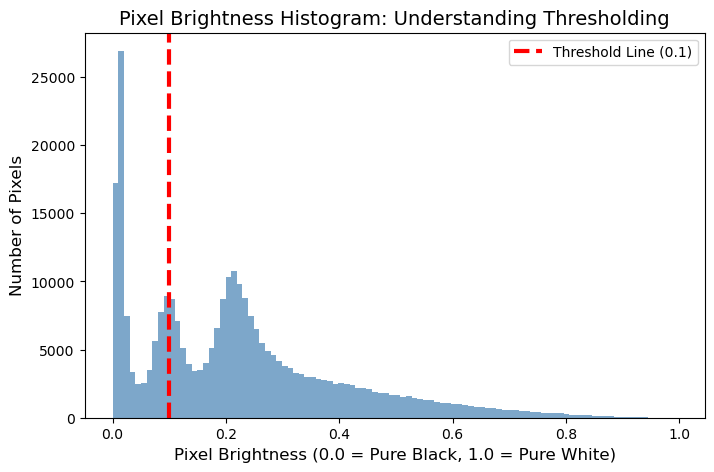

In [8]:
import matplotlib.pyplot as plt

# 1. Take our 2D grid of image pixels and flatten it into a single, long list
# We will use 'blurred_image' from the previous step.
# (Assuming the image brightness was scaled between 0 and 1)
all_pixels = blurred_image.ravel()

# 2. Pick a "Global" Threshold value for this demonstration
# Let's say any pixel brighter than 0.3 is considered part of a cell
example_threshold = 0.1

# 3. Set up the canvas for our graph
plt.figure(figsize=(8, 5))

# 4. Plot the Histogram!
# 'bins=100' means we are sorting the pixels into 100 different brightness buckets
plt.hist(all_pixels, bins=100, color='steelblue', alpha=0.7)

# 5. Draw a thick red line to represent our Threshold
plt.axvline(x=example_threshold, color='red', linestyle='--', linewidth=3,
            label=f'Threshold Line ({example_threshold})')

# 6. Add some nice labels so we know what we are looking at
plt.title("Pixel Brightness Histogram: Understanding Thresholding", fontsize=14)
plt.xlabel("Pixel Brightness (0.0 = Pure Black, 1.0 = Pure White)", fontsize=12)
plt.ylabel("Number of Pixels", fontsize=12)
plt.legend()

# 7. Show the graph!
plt.show()

#Step 4) The Parallel Processing Pipeline
To run code in parallel, we first need to pack all of our step-by-step instructions into a single Function (a reusable block of code). Then, we tell our "kitchen of chefs" to run that function on every frame in the video simultaneously.

In [9]:
import numpy as np
import pandas as pd
from skimage import exposure, filters, morphology, measure, segmentation, feature
from scipy import ndimage as ndi
from joblib import Parallel, delayed  # These are our "Kitchen Managers" for parallelization

# 1. We create a "Function" that contains all our instructions for a single frame
def process_single_frame(t):
    # Grab the specific frame for both channels
    frame_his = img_his[t]
    frame_kni = img_kni[t]

    # --- A. Preprocess the Histone Image ---
    p1, p99 = np.percentile(frame_his, (1, 99.5))
    norm_his = exposure.rescale_intensity(frame_his, in_range=(p1, p99), out_range=(0, 1))
    blurred = filters.gaussian(norm_his, sigma=1)

    # --- B. Adaptive Threshold & Cleanup ---
    local_thresh = filters.threshold_local(blurred, block_size=35, offset=0.02)
    bw_adaptive = blurred > local_thresh
    bw_clean = morphology.remove_small_objects(bw_adaptive, min_size=15)
    bw_clean = morphology.remove_small_holes(bw_clean, area_threshold=15)

    # --- C. Chop Touching Cells Apart (Watershed) ---
    # Sometimes cells overlap. This math finds the exact center of each cell
    # and draws borders between them so they don't merge into one giant blob.
    distance = ndi.distance_transform_edt(bw_clean)
    coords = feature.peak_local_max(distance, footprint=np.ones((5, 5)), labels=bw_clean)
    local_maxi = np.zeros_like(bw_clean, dtype=bool)
    local_maxi[tuple(coords.T)] = True
    markers = ndi.label(local_maxi)[0]
    labels = segmentation.watershed(-distance, markers, mask=bw_clean)

    # --- D. Apply Mask to Knirps & Measure! ---
    # MAGIC HAPPENS HERE: We tell it to look at the shapes in 'labels' (Histone),
    # but measure the actual pixel brightness inside 'frame_kni' (Knirps)
    props = measure.regionprops(labels, intensity_image=frame_kni)

    # Create an empty list to hold the cells found in this specific frame
    frame_features = []

    for p in props:
        y, x = p.centroid
        frame_features.append({
            "frame": t,
            "x": x,
            "y": y,
            "area": p.area,
            "mean_knirps": p.intensity_mean  # Saving the Knirps brightness!
        })

    # Hand the list of cells back to the main program
    return frame_features

# ==========================================
# 2. RUN THE PARALLEL PROCESS
# ==========================================
print(f"Sending {num_frames} frames to the CPU chefs...")

# 'n_jobs=-1' tells the computer to use ALL available CPU cores.
# 'delayed' queues up the function for every frame from 0 to num_frames.
parallel_results = Parallel(n_jobs=-1)(delayed(process_single_frame)(t) for t in range(num_frames))

# The results come back as a list of lists (a list for every frame).
# We need to flatten it into one massive list of cells.
all_features = [cell for frame_list in parallel_results for cell in frame_list]

# 3. Convert our final list into our Excel-like table
df = pd.DataFrame(all_features)

print(f"Success! Measured {len(df)} total cells across all frames.")

Sending 111 frames to the CPU chefs...


/var/folders/vb/c6js107j1y7_pw6gnwh1yxg40000gp/T/ipykernel_36562/4249088691.py:21: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
/var/folders/vb/c6js107j1y7_pw6gnwh1yxg40000gp/T/ipykernel_36562/4249088691.py:21: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
/var/folders/vb/c6js107j1y7_pw6gnwh1yxg40000gp/T/ipykernel_3

Success! Measured 230780 total cells across all frames.


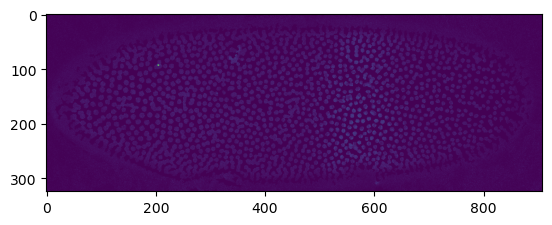

In [10]:
plt.imshow(bw_clean*img_kni[20])

# Step 5) Plotting the AP profile

Drawing profiles over AP...


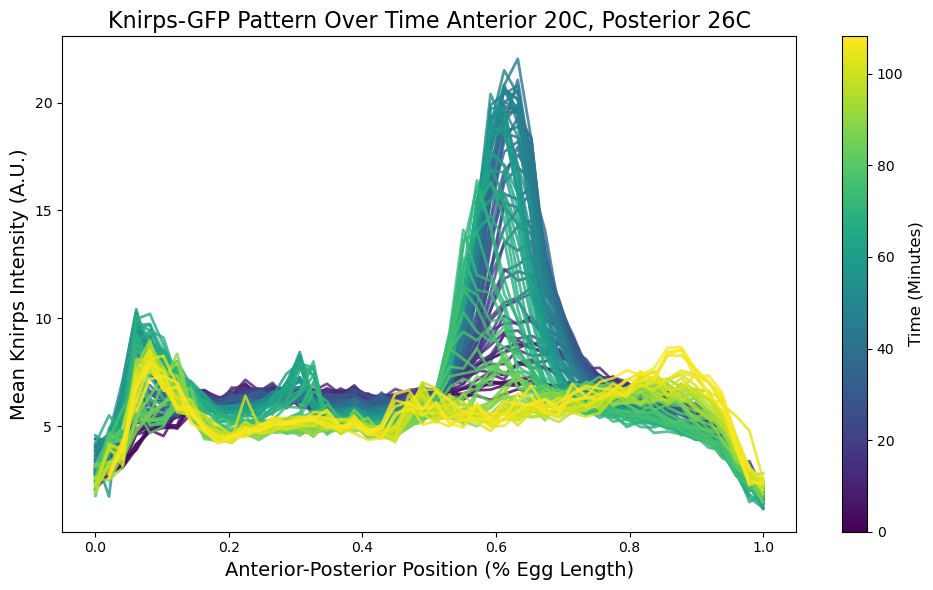

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# --- 1. Define Temporal Resolution ---
seconds_per_frame = 59
minutes_per_frame = seconds_per_frame / 60.0

# Calculate the maximum time in minutes for the colorbar scale
# (Subtract 1 because frame 0 represents minute 0)
max_time_minutes = (num_frames - 1) * minutes_per_frame

# --- 2. Calculate Egg Length Percentage ---
# Find out exactly how wide the original image is in pixels
image_width = img_his.shape[2]

# Convert the raw 'x' pixel coordinate into a fraction from 0.0 to 1.0
df['ap_position'] = df['x'] / image_width

# --- 3. Slice the Embryo into Bins ---
# We chop the embryo into 50 vertical slices to smooth out the data
num_bins = 50

# The 'pd.cut' tool assigns every cell to one of these 50 slices based on its ap_position
df['AP_Bin'] = pd.cut(df['ap_position'], bins=num_bins, labels=np.linspace(0, 1, num_bins))

# --- 4. Calculate Averages ---
# Group the data by Frame AND by Bin, then calculate the mean Knirps intensity
binned_data = df.groupby(['frame', 'AP_Bin'], observed=True)['mean_knirps'].mean().reset_index()

# Add a real-world time column to the dataframe for future calculations
binned_data['time_minutes'] = binned_data['frame'] * minutes_per_frame

# --- 5. Set Up the Graph Canvas ---
fig, ax = plt.subplots(figsize=(10, 6))

# Generate a list of colors scaling from 0 to 1 across all our frames
colors = cm.viridis(np.linspace(0, 1, num_frames))

# --- 6. Draw the Lines! ---
print("Drawing profiles over AP...")

for t in range(num_frames):
    # Filter the data so we are only looking at frame 't'
    time_data = binned_data[binned_data['frame'] == t]

    # Plot this frame's line (lw = line width, alpha = transparency)
    ax.plot(time_data['AP_Bin'], time_data['mean_knirps'],
            color=colors[t], lw=2, alpha=0.8)

# --- 7. Add Labels and Formatting ---
ax.set_title('Knirps-GFP Pattern Over Time Anterior 20C, Posterior 26C', fontsize=16)
ax.set_xlabel('Anterior-Posterior Position (% Egg Length)', fontsize=14)
ax.set_ylabel('Mean Knirps Intensity (A.U.)', fontsize=14)

# THE FIX: Create a colorbar mapped to actual MINUTES instead of frames
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=max_time_minutes))
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Time (Minutes)', fontsize=12)

plt.tight_layout()
plt.show()

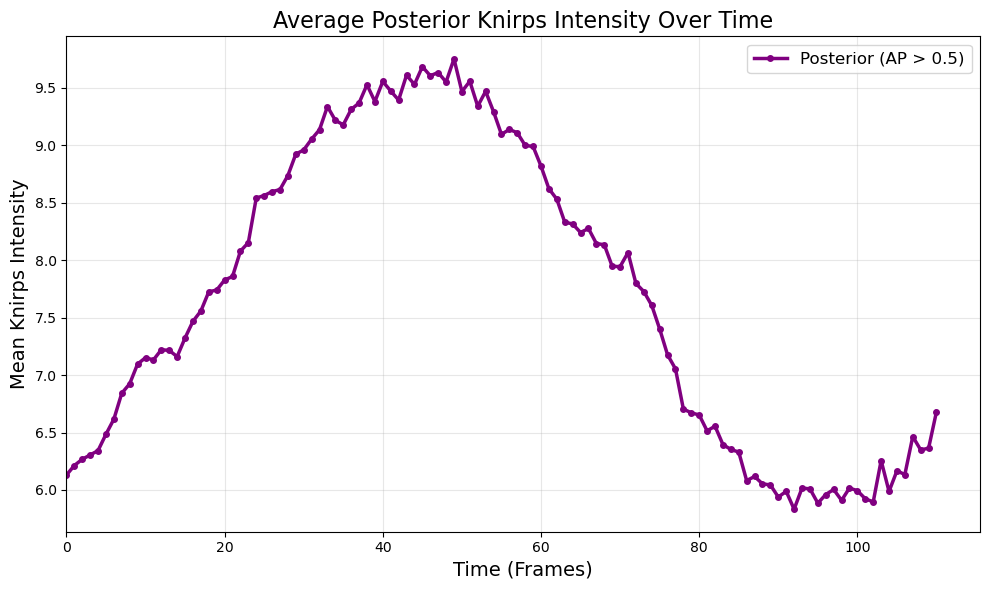

In [12]:
import matplotlib.pyplot as plt

# --- 1. Convert Pixels to Fractional AP Position ---
# We assume the x-axis corresponds to the AP axis.
# By dividing by the maximum x-coordinate, we map the embryo from 0.0 to 1.0.
# (If your embryo doesn't fill the whole image, replace df['x'].max() with the actual pixel width of the embryo)
image_width = df['x'].max()
df['ap_position'] = df['x'] / image_width

# --- 2. Isolate the Posterior Cells ---
# Filter the DataFrame to only keep cells where the AP position is greater than 0.5
posterior_cells = df[df['ap_position'] > 0.5]

# --- 3. Calculate the Average per Frame ---
# The Pandas .groupby() function is perfect here. It groups all the remaining cells
# by their 'frame' number, and then calculates the mean of their Knirps intensity.
posterior_intensity_over_time = posterior_cells.groupby('frame')['mean_knirps'].mean()

# --- 4. Plot the Results ---
fig, ax = plt.subplots(figsize=(10, 6))

# The index of our grouped data is the frame number, and the values are the average intensities
ax.plot(posterior_intensity_over_time.index,
        posterior_intensity_over_time.values,
        color='purple',
        linewidth=2.5,
        marker='o',
        markersize=4,
        label='Posterior (AP > 0.5)')

# Formatting
ax.set_title('Average Posterior Knirps Intensity Over Time', fontsize=16)
ax.set_xlabel('Time (Frames)', fontsize=14)
ax.set_ylabel('Mean Knirps Intensity', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

# Set the x-axis limits to start at frame 0
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

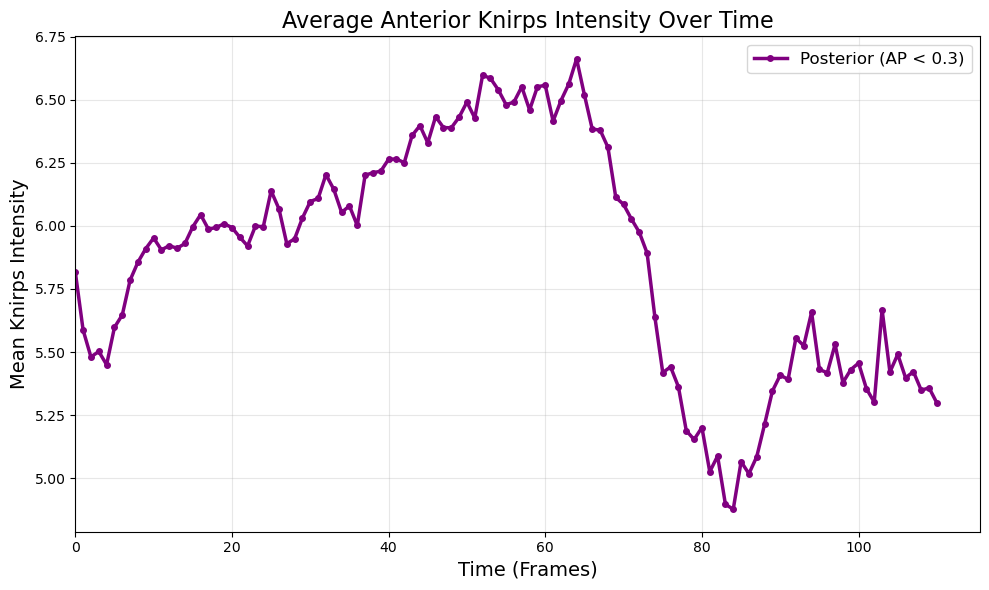

In [13]:
import matplotlib.pyplot as plt

# --- 1. Convert Pixels to Fractional AP Position ---
# We assume the x-axis corresponds to the AP axis.
# By dividing by the maximum x-coordinate, we map the embryo from 0.0 to 1.0.
# (If your embryo doesn't fill the whole image, replace df['x'].max() with the actual pixel width of the embryo)
image_width = df['x'].max()
df['ap_position'] = df['x'] / image_width

# --- 2. Isolate the Posterior Cells ---
# Filter the DataFrame to only keep cells where the AP position is greater than 0.5
posterior_cells = df[df['ap_position'] < 0.3]

# --- 3. Calculate the Average per Frame ---
# The Pandas .groupby() function is perfect here. It groups all the remaining cells
# by their 'frame' number, and then calculates the mean of their Knirps intensity.
posterior_intensity_over_time = posterior_cells.groupby('frame')['mean_knirps'].mean()

# --- 4. Plot the Results ---
fig, ax = plt.subplots(figsize=(10, 6))

# The index of our grouped data is the frame number, and the values are the average intensities
ax.plot(posterior_intensity_over_time.index,
        posterior_intensity_over_time.values,
        color='purple',
        linewidth=2.5,
        marker='o',
        markersize=4,
        label='Posterior (AP < 0.3)')

# Formatting
ax.set_title('Average Anterior Knirps Intensity Over Time', fontsize=16)
ax.set_xlabel('Time (Frames)', fontsize=14)
ax.set_ylabel('Mean Knirps Intensity', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

# Set the x-axis limits to start at frame 0
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

#Step 6) Visualizing Space and Time as a Heatmap
Before we can draw a heatmap, our data table is currently too "long." It just lists row after row of data. We need to reshape it into a 2D grid (a matrix), just like a Sudoku board.
We use a Pivot Table to do this. We tell the computer: "Make the Rows represent Time, make the Columns represent Space, and fill in the grid cells with the Knirps brightness.

/var/folders/vb/c6js107j1y7_pw6gnwh1yxg40000gp/T/ipykernel_36562/993002171.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  kymo_matrix = binned_data.pivot_table(index='time_minutes', columns='AP_Bin', values='mean_knirps')


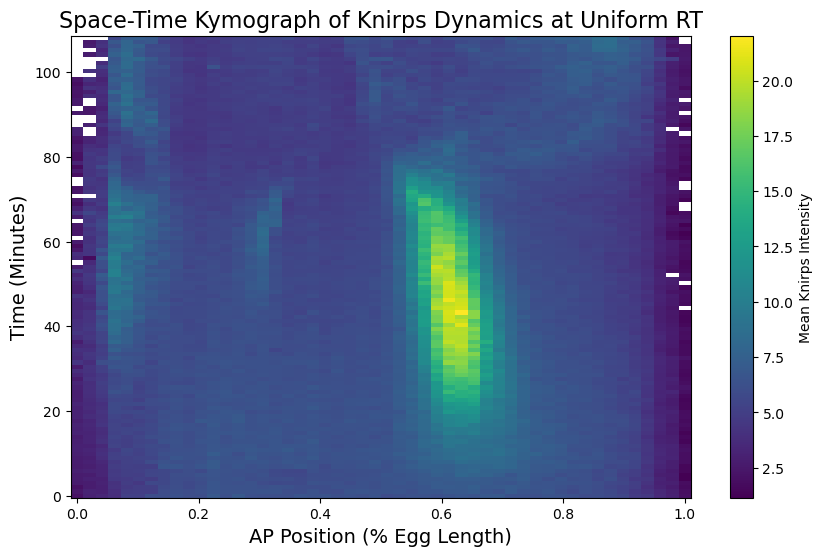

In [14]:
# --- 1. Reshape the Data ---
# Pivot the 'binned_data' into a 2D matrix
# THE FIX: We use 'time_minutes' as the index so the Y-axis is plotted in physical time
kymo_matrix = binned_data.pivot_table(index='time_minutes', columns='AP_Bin', values='mean_knirps')

# --- 2. Set Up the Graph Canvas ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- 3. Draw the Heatmap! ---
# 'pcolormesh' is the tool that draws our colored grid
mesh = ax.pcolormesh(
    kymo_matrix.columns,   # The X-axis (Space: AP Position)
    kymo_matrix.index,     # The Y-axis (Time: Minutes)
    kymo_matrix.values,    # The Colors (Knirps Brightness)
    cmap='viridis',        # The color palette (purple to yellow)
    shading='auto',         # Smooths out the blocky edges.

)

# --- 4. Add Labels and Formatting ---
ax.set_title('Space-Time Kymograph of Knirps Dynamics at Uniform RT', fontsize=16)
ax.set_xlabel('AP Position (% Egg Length)', fontsize=14)

# THE FIX: Update the Y-axis label to reflect the new time units
ax.set_ylabel('Time (Minutes)', fontsize=14)

# Add a colorbar to the side as a legend
fig.colorbar(mesh, ax=ax, label='Mean Knirps Intensity')

# Show the graph
plt.show()

# Particle Image Velocimetry

In [15]:
def stretch_contrast(img, low=2, high=98):
    p_low, p_high = np.percentile(img, (low, high))
    img = np.clip((img - p_low) / (p_high - p_low + 1e-9), 0, 1)
    return img

In [16]:
import numpy as np
from skimage import io, exposure
import cv2
import imageio
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Load TIFF stack (T, Y, X)
# ------------------------------------------------------------
stack = io.imread(path_his).astype(np.float32)
T, Y, X = stack.shape

# ------------------------------------------------------------
# 2) Contrast enhancement for low-SNR nuclei
#    (CLAHE + percentile stretching)
# ------------------------------------------------------------
def enhance_nuclei(img):
    # normalize
    img = img - img.min()
    img = img / (img.max() + 1e-9)

    # CLAHE (adaptive histogram equalization)
    img = exposure.equalize_adapthist(img, clip_limit=0.02)

    # stretch contrast to remove dim tails
    p1, p99 = np.percentile(img, (1, 99))
    img = np.clip((img - p1) / (p99 - p1 + 1e-9), 0, 1)

    return img

enhanced = np.zeros_like(stack, dtype=np.float32)
for t in range(T):
    enhanced[t] = stretch_contrast(stack[t], low=30, high=99)

# ------------------------------------------------------------
# 3) Compute optic flow (Farneback)
#     Returns flow_u (x-component) and flow_v (y-component)
# ------------------------------------------------------------
flow_u = np.zeros_like(stack)
flow_v = np.zeros_like(stack)

for t in range(T - 1):
    img1 = (enhanced[t] * 255).astype(np.uint8)
    img2 = (enhanced[t+1] * 255).astype(np.uint8)

    flow = cv2.calcOpticalFlowFarneback(
        img1, img2, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )

    flow_u[t] = flow[..., 0]
    flow_v[t] = flow[..., 1]

# Last frame has no flow
flow_u[-1] = 0
flow_v[-1] = 0

# ------------------------------------------------------------
# 4) Compute GLOBAL max flow for consistent color scale
# ------------------------------------------------------------
max_right = np.max(np.clip(flow_u, 0, None))
max_left  = np.max(np.clip(-flow_u, 0, None))

max_right = max_right if max_right > 0 else 1e-9
max_left  = max_left if max_left > 0 else 1e-9

# ------------------------------------------------------------
# 5) Generate GIF: enhanced nuclei + red/blue motion overlay
# ------------------------------------------------------------
frames = []
T_show = T

for t in range(T_show):
    img = enhanced[t]

    # prepare gray→RGB base image
    base = np.dstack([img, img, img])

    u = flow_u[t]

    motion = np.zeros((Y, X, 3), dtype=np.float32)
    motion[..., 0] = np.clip(u, 0, None) / max_right       # right = red
    motion[..., 2] = np.clip(-u, 0, None) / max_left       # left  = blue

    # blend
    overlay = 0.7 * base + 0.9 * motion
    overlay = np.clip(overlay, 0, 1)

    frames.append((overlay * 255).astype(np.uint8))

# save slower GIF (0.18 s per frame)
imageio.mimsave("flow_overlay_constant_scale.gif", frames, duration=350)

print("Saved: flow_overlay_constant_scale.gif")

Saved: flow_overlay_constant_scale.gif


In [17]:

import io
import numpy as np
import matplotlib.pyplot as plt
import imageio

T = stack.shape[0]
gif_frames_arrows = []

# downsample vectors so arrows are not too dense
step = 30

for t in range(T):
    # img = stack[t].astype(np.float32)
    # img=stretch_contrast(stack[t], low=70, high=99)
    # img = img - img.min()
    # img = img / (img.max() + 1e-9)

    img=enhanced[t]
    u = flow_u[t]
    v = flow_v[t]

    Y, X = img.shape

    Xg, Yg = np.meshgrid(np.arange(0, X, step),
                         np.arange(0, Y, step))

    U = u[::step, ::step]
    V = v[::step, ::step]

    fig, ax = plt.subplots(figsize=(6,4), dpi=300)
    ax.imshow(img, cmap="gray")
    ax.quiver(
        Xg, Yg,
        U, V,
        color="orchid",
        angles="xy",
        scale_units="xy",
        scale=0.3,       # ↓ smaller number → longer arrows
        alpha=0.7,
        width=0.004      # optional: slightly thicker arrows
    )

    ax.set_axis_off()
    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    gif_frames_arrows.append(buf)

    plt.close(fig)

imageio.mimsave("flow_arrows_longer.gif", gif_frames_arrows, duration=300)
print("Saved: flow_arrows_longer.gif")




Saved: flow_arrows_longer.gif


Calculating regional velocities across 111 frames...


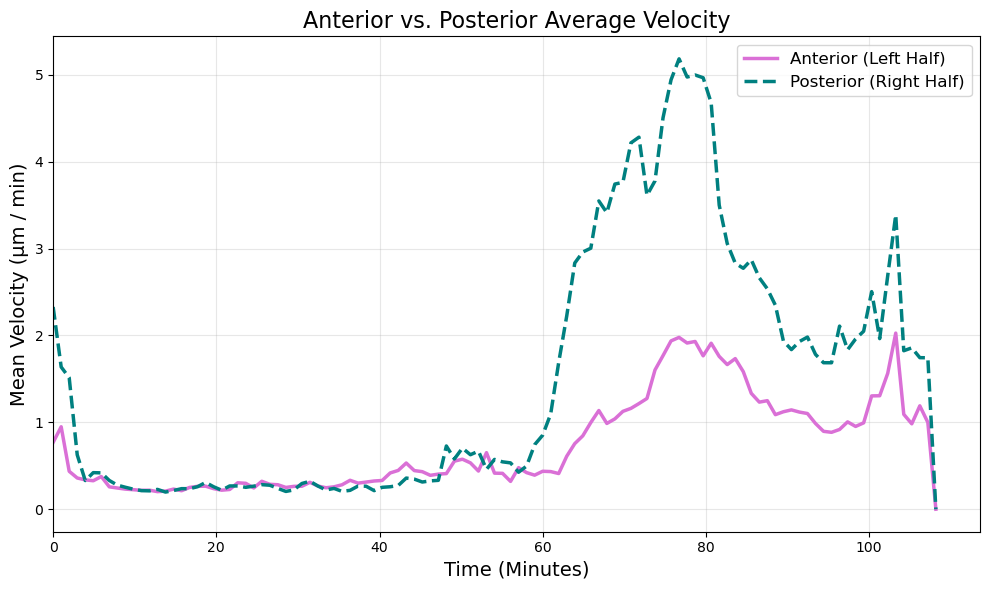

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Physical Calibrations ---               # Microns per pixel

pixel_width = 0.568
z_step_size = 2.885
seconds_per_frame = 59
minutes_per_frame = seconds_per_frame / 60.0

# Get the total frames (T) and image dimensions (Y, X)
T, Y, X = flow_u.shape

# Find the exact middle column of the image
mid_x = X // 2

# Create empty lists to store our average speeds for each frame
ant_speeds = []
post_speeds = []

print(f"Calculating regional velocities across {T} frames...")

for t in range(T):
    # Grab the horizontal and vertical flows for this specific frame
    u = flow_u[t]
    v = flow_v[t]

    # Calculate the absolute speed in pixels per frame
    speed_pixels = np.sqrt(u**2 + v**2)

    # CONVERT TO PHYSICAL UNITS (Microns per Minute)
    speed_microns_per_min = speed_pixels * (pixel_width / minutes_per_frame)

    # Wield numpy slicing to physically cut the matrix in half!
    ant_region = speed_microns_per_min[:, :mid_x]
    post_region = speed_microns_per_min[:, mid_x:]

    # Calculate the mean speed for these halves and save them
    ant_speeds.append(np.mean(ant_region))
    post_speeds.append(np.mean(post_region))

# --- 2. Create the Physical Time Array ---
# Create an array that maps frame numbers [0, 1, 2...] to minutes [0, 2.58, 5.16...]
time_array = np.arange(T) * minutes_per_frame

# ==========================================
# PLOT THE RESULTS
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Anterior
# THE FIX: Replace range(T) with time_array
ax.plot(time_array, ant_speeds,
        label='Anterior (Left Half)',
        color='orchid',
        linewidth=2.5)

# Plot Posterior
ax.plot(time_array, post_speeds,
        label='Posterior (Right Half)',
        color='teal',
        linewidth=2.5,
        linestyle='--')

# Formatting
ax.set_title('Anterior vs. Posterior Average Velocity', fontsize=16)

# THE FIX: Update labels to reflect physical units
ax.set_xlabel('Time (Minutes)', fontsize=14)
ax.set_ylabel('Mean Velocity (µm / min)', fontsize=14)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

# Ensure the X-axis starts at 0
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

#Cephalic furrow tracking

In [19]:
pip install roifile

Note: you may need to restart the kernel to use updated packages.


In [20]:
import os
import glob
import re
import pandas as pd
import numpy as np
from roifile import roiread

# 1. Point this to your folder containing all the time-point zip files
folder_path = '/Users/hugo/Desktop/fall_2026_temperature_analysis/2026_04_04_cf_timecourse/'

raw_files = glob.glob(os.path.join(folder_path, '*.zip'))

# Custom rule to sort by the physical number inside the filename (e.g. t1, t2, t10)
def extract_time_number(filepath):
    filename = os.path.basename(filepath)
    numbers = re.findall(r'\d+', filename)
    return int(numbers[0]) if numbers else 0

zip_files = sorted(raw_files, key=extract_time_number)

# 2. Define physical resolution
xy_pixel_size = 0.568
z_step_size = 2.885

all_data = []
print(f"Found {len(zip_files)} time points. Building 4D dataset...")

# 3. Loop through every time point
for t_idx, zip_file in enumerate(zip_files):
    rois = roiread(zip_file)

    # Loop through every Z-slice within this time point
    for z_idx, roi in enumerate(rois):
        coords = roi.coordinates()
        raw_x = coords[:, 0]
        raw_y = coords[:, 1]

        # Convert to physical microns
        x_um = raw_x * xy_pixel_size
        y_um = raw_y * xy_pixel_size
        z_um = np.full_like(raw_x, z_idx * z_step_size)

        for i in range(len(x_um)):
            all_data.append({
                'time_frame': extract_time_number(zip_file),
                'z_slice': z_idx,
                'ap_microns': x_um[i],
                'depth_microns': z_um[i],
                'dv_microns': y_um[i]
            })

# 4. Compile into the Master DataFrame
df_4d = pd.DataFrame(all_data)
print(f"Success! Master 4D Dataset created with {len(df_4d)} coordinates.")


Found 33 time points. Building 4D dataset...
Success! Master 4D Dataset created with 1397 coordinates.


In [21]:
import numpy as np
import plotly.graph_objects as go

def plot_swapped_native_space(df, frame_target, roll_angle_deg, embryo_length=450.09, embryo_width=186.93):
    frame_data = df[df['time_frame'] == frame_target].copy()

    # 1. DEFINE THE NATIVE FIJI CENTER
    X_c = embryo_length / 2.0
    Y_c = embryo_width / 2.0
    Z_c = embryo_width / 2.0

    a, b, c = X_c, Y_c, Z_c

    # Extract native raw tracking coordinates
    X_fiji = frame_data['ap_microns'].values
    Y_fiji = frame_data['dv_microns'].values
    depth_fiji = frame_data['depth_microns'].values

    # 2. ORTHOGRAPHIC SURFACE DROP
    rad_term = 1.0 - ((X_fiji - X_c)**2 / a**2) - ((Y_fiji - Y_c)**2 / b**2)
    rad_term = np.clip(rad_term, 0, None)

    # Z_surf is the top coverslip curve
    Z_surf = Z_c - (c * np.sqrt(rad_term))
    Z_true = Z_surf + depth_fiji

    # 3. APPLY ROLL AROUND THE EMBRYO CENTER
    theta = np.radians(roll_angle_deg)

    Y_shift = Y_fiji - Y_c
    Z_shift = Z_true - Z_c

    Y_rot = Y_shift * np.cos(theta) - Z_shift * np.sin(theta)
    Z_rot = Y_shift * np.sin(theta) + Z_shift * np.cos(theta)

    Y_final_dv = Y_rot + Y_c
    Z_final_depth = Z_rot + Z_c

    # ==========================================
    # VISUALIZATION WITH PLOTLY (AXES SWAPPED)
    # ==========================================
    fig = go.Figure()

    # --- A. Generate the Ellipsoid Shell ---
    u = np.linspace(0, np.pi, 40)
    v = np.linspace(0, 2 * np.pi, 40)
    U, V = np.meshgrid(u, v)

    Math_X = X_c + a * np.cos(U)
    Math_Y_dv = Y_c + b * np.sin(U) * np.cos(V)
    Math_Z_depth = Z_c + c * np.sin(U) * np.sin(V)

    fig.add_trace(go.Surface(
        x=Math_X,
        y=Math_Z_depth,
        z=Math_Y_dv,
        colorscale='Greys',
        showscale=False,
        opacity=0.15,
        name='Embryo Shell'
    ))

    # --- B. Generate the Canonical Ventral Furrow (Reference Line) ---
    # The VF runs pole-to-pole along X, at the bottom-most curve of Y, at mid-depth Z.
    vf_x = np.linspace(0, embryo_length, 100)

    # Calculate the curved profile of the shell along the AP axis
    rad_term_vf = 1.0 - ((vf_x - X_c)**2 / a**2)
    rad_term_vf = np.clip(rad_term_vf, 0, None)

    vf_y_native = Y_c + b * np.sqrt(rad_term_vf) # The curved "bottom" edge
    vf_z_native = np.full_like(vf_x, Z_c)        # Dead-center of the depth axis

    # PLOTLY SWAP FOR VF LINE (X -> AP, Y -> Depth, Z -> DV)
    fig.add_trace(go.Scatter3d(
        x=vf_x,
        y=vf_z_native,
        z=vf_y_native,
        mode='lines',
        line=dict(color='red', width=6, dash='dash'),
        name='Canonical Ventral Furrow'
    ))

    # --- C. Plot the Rolled Cleavage Furrows ---
    fig.add_trace(go.Scatter3d(
        x=X_fiji,
        y=Z_final_depth,
        z=Y_final_dv,
        mode='markers',
        marker=dict(
            size=5,
            color=depth_fiji,
            colorscale='Viridis',
            opacity=0.9,
            line=dict(color='black', width=1),
            colorbar=dict(title='Fiji Depth (µm)', thickness=15, len=0.6)
        ),
        name='Cleavage Furrows'
    ))

    # --- Formatting ---
    fig.update_layout(
        title=f'3D Cephalic Furrow',
        scene=dict(
            aspectmode='data',
            xaxis_title='AP Axis (microns)',
            yaxis_title='Depth (microns)',
            zaxis_title='DV Axis (microns)',
            zaxis=dict(autorange='reversed')
        ),
        margin=dict(l=0, r=0, b=0, t=50)
    )

    fig.show()

# Run it
plot_swapped_native_space(df_4d, frame_target=10, roll_angle_deg=0)

Rendering 33 frames with fixed cinematic camera...
Done! Animation saved to cephalic_furrow_cinematic_fixed.mp4


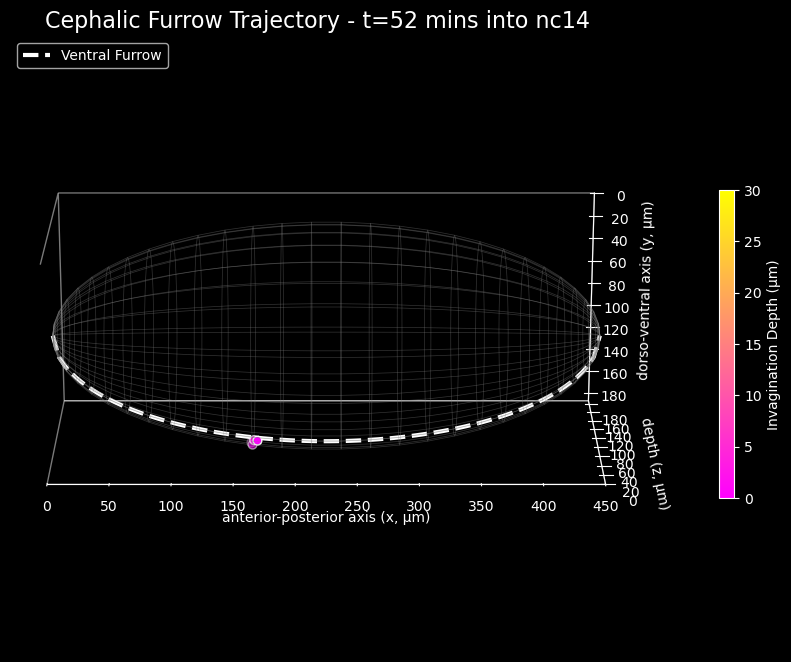

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 1. CORE TRANSFORMATION ENGINE
# ==========================================
def apply_orthographic_roll(df_frame, roll_angle_deg=23.8, embryo_length=450.09, embryo_width=186.93):
    X_c, Y_c, Z_c = embryo_length / 2.0, embryo_width / 2.0, embryo_width / 2.0
    a, b, c = X_c, Y_c, Z_c

    X_fiji = df_frame['ap_microns'].values
    Y_fiji = df_frame['dv_microns'].values
    depth_fiji = df_frame['depth_microns'].values

    # Orthographic drop
    rad_term = np.clip(1.0 - ((X_fiji - X_c)**2 / a**2) - ((Y_fiji - Y_c)**2 / b**2), 0, None)
    Z_surf = Z_c - (c * np.sqrt(rad_term))
    Z_true = Z_surf + depth_fiji

    # Rotation
    theta = np.radians(roll_angle_deg)
    Y_shift = Y_fiji - Y_c
    Z_shift = Z_true - Z_c

    Y_rot = Y_shift * np.cos(theta) - Z_shift * np.sin(theta)
    Z_rot = Y_shift * np.sin(theta) + Z_shift * np.cos(theta)

    # Map to final axes (DV -> Z, Depth -> Y)
    final_X = X_fiji
    final_Y_depth = Z_rot + Z_c
    final_Z_dv = Y_rot + Y_c

    return final_X, final_Y_depth, final_Z_dv, depth_fiji

# ==========================================
# 2. ANIMATION SETUP
# ==========================================
# Extract unique time frames
time_frames = sorted(df_4d['time_frame'].unique())

# --- THE ALL-BLACK STYLE ---
plt.style.use('dark_background')
fig = plt.figure(figsize=(12, 8), facecolor='black')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')

# Fixed geometric parameters
L, W = 450.09, 186.93
X_c, Y_c, Z_c = L/2, W/2, W/2

# --- Draw Static Background Elements ---
# A. The Ellipsoid Wireframe
u = np.linspace(0, np.pi, 30)
v = np.linspace(0, 2 * np.pi, 30)
U, V = np.meshgrid(u, v)
Math_X = X_c + (L/2) * np.cos(U)
Math_Y_depth = Z_c + (W/2) * np.sin(U) * np.sin(V)
Math_Z_dv = Y_c + (W/2) * np.sin(U) * np.cos(V)

ax.plot_wireframe(Math_X, Math_Y_depth, Math_Z_dv, color='gray', alpha=0.4, linewidth=0.5)

# B. The Ventral Furrow Reference Line
vf_x = np.linspace(0, L, 100)
rad_term_vf = np.clip(1.0 - ((vf_x - X_c)**2 / (L/2)**2), 0, None)
vf_z_dv = Y_c + (W/2) * np.sqrt(rad_term_vf)
vf_y_depth = np.full_like(vf_x, Z_c)

ax.plot(vf_x, vf_y_depth, vf_z_dv, color='white', linewidth=3, linestyle='--', label='Ventral Furrow')

# C. Initialize Empty Scatter Plot (THE GLOW)
scatter = ax.scatter([], [], [], c=[], cmap='spring', s=40, edgecolors='white', linewidth=1, vmin=0, vmax=30)
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Invagination Depth (µm)', color='white')

# D. Strict Axis Locking with White Style
ax.set_xlim(0, L)
ax.set_ylim(0, W)
ax.set_zlim(W, 0) # Inverted Z-axis to match Fiji top-down view

ax.set_box_aspect([1, W/L, W/L])
ax.set_xlabel('anterior-posterior axis (x, µm)', color='white')
ax.set_ylabel('depth (z, µm)', color='white')
ax.set_zlabel('dorso-ventral axis (y, µm)', color='white')
ax.tick_params(colors='white')
ax.legend(loc='upper left', labelcolor='white')

# E. The White Axis Lines
ax.xaxis.line.set_color('white')
ax.yaxis.line.set_color('white')
ax.zaxis.line.set_color('white')

# Clean up the background panes
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(False)

# --- LOCK THE CAMERA ANGLE ---
ax.view_init(elev=20, azim=-90)

title_text = ax.set_title('', fontsize=16, color='white')

# ==========================================
# 3. ANIMATION UPDATE LOOP (FIXED CAMERA)
# ==========================================
def update(frame_idx):
    # --- Data Update ---
    t = time_frames[frame_idx]
    df_t = df_4d[df_4d['time_frame'] == t]

    if len(df_t) > 0:
        X, Y_depth, Z_dv, depths = apply_orthographic_roll(df_t, roll_angle_deg=23.8)
        scatter._offsets3d = (X, Y_depth, Z_dv)
        scatter.set_array(depths)

    # Updated biological time title
    title_text.set_text(f'Cephalic Furrow Trajectory - t={t+52} mins into nc14')

    # Camera remains static, so no ax.view_init() call is needed here

    return scatter, title_text

# ==========================================
# 4. RENDER & SAVE
# ==========================================
print(f"Rendering {len(time_frames)} frames with fixed cinematic camera...")

anim = FuncAnimation(fig, update, frames=len(time_frames), interval=200, blit=False)

# Save to an MP4 video file
output_filename = 'cephalic_furrow_cinematic_fixed.mp4'
anim.save(output_filename, fps=5, extra_args=['-vcodec', 'libx264'])
print(f"Done! Animation saved to {output_filename}")